# Diabetetes and hipertension prediction

In [2275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score,confusion_matrix,f1_score
%matplotlib inline

In [2276]:
df=pd.read_csv(r"C:\artificial_intelligence_coarse\mydatasetkaggle\diabetes_prediction_dataset.csv")

In [2277]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2278]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [2279]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [2280]:
df.shape

(100000, 9)

In [2281]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2282]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [2283]:
df.gender.unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [2284]:
df.smoking_history.unique()

<StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

In [2285]:
df.duplicated().sum()

np.int64(3854)

In [2286]:
df=df.drop_duplicates()

In [2287]:
df.describe()

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [2288]:
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  str    
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  str    
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.3 MB


In [2289]:
df.gender.value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [2290]:
df.smoking_history.value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [2291]:
df.diabetes.value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

Text(0, 0.5, 'number of patient')

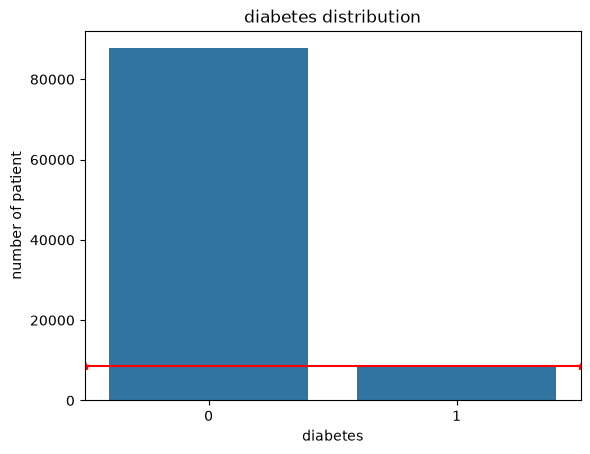

In [2292]:
sns.countplot(data=df,x='diabetes')
plt.axhline(sum(df['diabetes']==1),color='red',marker='*')
plt.title("diabetes distribution")
plt.ylabel("number of patient")

In [2293]:
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  str    
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  str    
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.3 MB


In [2294]:
numeric=['age','hypertension','heart_disease','bmi','HbA1c_level','blood_glucose_level']

In [2295]:
df[numeric].corrwith(df['diabetes']).sort_values(ascending=False)

blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
dtype: float64

In [2296]:
df[numeric].corr()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000


<Axes: >

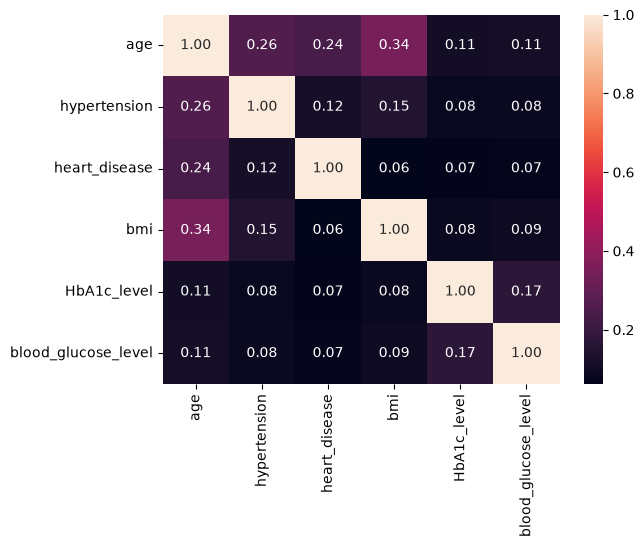

In [2297]:
sns.heatmap(data=df[numeric].corr(),annot=True,fmt='.2f')

In [2298]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2299]:
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  str    
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  str    
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.3 MB


In [2300]:
pd.crosstab(df['smoking_history'],df.diabetes,normalize='index')*100

diabetes,0,1
smoking_history,,
No Info,95.606167,4.393833
current,89.692291,10.307709
ever,88.194097,11.805903
former,82.901387,17.098613
never,90.298855,9.701145
not current,89.162871,10.837129


In [2301]:
pd.crosstab(df['gender'],df['diabetes'],normalize='index')*100

diabetes,0,1
gender,,
Female,92.081694,7.918306
Male,89.904171,10.095829
Other,100.000000,0.000000


In [2302]:
categorical=df[['gender','smoking_history']]

In [2303]:
categorical

,gender,smoking_history
0,Female,never
1,Female,No Info
2,Male,never
3,Female,current
4,Male,current
...,...,...
99994,Female,No Info
99996,Female,No Info
99997,Male,former
99998,Female,never


In [2304]:
df.gender.unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [2305]:
df.smoking_history.unique()

<StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

In [2306]:
binary=df[['hypertension','heart_disease']]


In [2307]:
binary

,hypertension,heart_disease
0,0,1
1,0,0
2,0,0
3,0,0
4,1,1
...,...,...
99994,0,0
99996,0,0
99997,0,0
99998,0,0


In [2308]:
numeric

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level']

In [2309]:
numeric.remove('hypertension')

In [2310]:
numeric

['age', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [2311]:
numeric.remove('heart_disease')

In [2312]:
numeric

['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [2313]:
dfencoded=pd.get_dummies(df,columns=['gender','smoking_history'],dtype=int)

In [2314]:
dfencoded

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36.0,0,0,24.60,4.8,145,0,1,0,0,1,0,0,0,0,0
99996,2.0,0,0,17.37,6.5,100,0,1,0,0,1,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,0,0,1,0,0,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,1,0,0,0,0,0,0,1,0


In [2315]:
dfencoded.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0


In [2316]:
x=dfencoded.drop('diabetes',axis=1)

In [2317]:
y=dfencoded['diabetes']

In [2318]:
x.shape

(96146, 15)

In [2319]:
y.shape

(96146,)

In [2320]:
xtr,xtt,ytr,ytt=train_test_split(x,y,test_size=0.4,random_state=42)

In [2321]:
xtr.shape

(57687, 15)

In [2322]:
ytr.shape

(57687,)

In [2323]:
xtt.shape

(38459, 15)

In [2324]:
ytt.shape

(38459,)

In [2325]:
mean=xtr[numeric].mean()
mean

age                     41.732512
bmi                     27.308385
HbA1c_level              5.532085
blood_glucose_level    138.140846
dtype: float64

In [2326]:
std=xtr[numeric].std()
std

age                    22.462788
bmi                     6.792608
HbA1c_level             1.071168
blood_glucose_level    40.961871
dtype: float64

In [2327]:
xtr_scaled=xtr.copy()
xtt_scaled=xtt.copy()

In [2328]:
xtr_scaled[numeric]=(xtr[numeric]-mean)/std
xtt_scaled[numeric]=(xtt[numeric]-mean)/std

In [2329]:
diabetespredictor=LogisticRegression(max_iter=1000,class_weight='balanced')

In [2330]:
diabetespredictor.fit(xtr_scaled,ytr)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [2331]:
predvalue=diabetespredictor.predict(xtt_scaled)

In [2332]:
sum(predvalue>0)

np.int64(7080)

In [2333]:
sum(ytt>0)

3425

In [2334]:
acscorelogreg=accuracy_score(y_true=ytt,y_pred=predvalue)
acscorelogreg

0.8846303856054499

In [2335]:
f1scrlogreg=f1_score(ytt,y_pred=predvalue)
f1scrlogreg

0.5776297001427891

In [2336]:
cmlogreg=confusion_matrix(ytt,predvalue)
cmlogreg

array([[30988,  4046],
       [  391,  3034]])

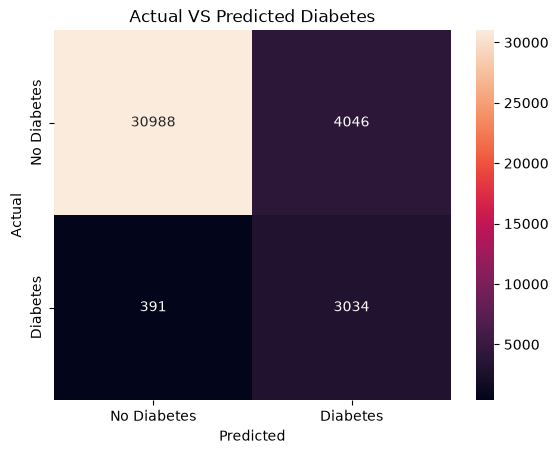

In [2337]:
sns.heatmap(data=cmlogreg,annot=True,fmt='d',xticklabels=['No Diabetes','Diabetes'],yticklabels=['No Diabetes','Diabetes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Actual VS Predicted Diabetes")
plt.show()

In [2338]:
from sklearn.neighbors import KNeighborsClassifier

In [2339]:
knn=KNeighborsClassifier(n_neighbors=5)

In [2340]:
knn.fit(xtr_scaled,ytr)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [2341]:
pknn=knn.predict(xtt_scaled)
pknn

array([0, 0, 1, ..., 0, 0, 0], shape=(38459,))

In [2342]:
sum(pknn>0)

np.int64(2366)

In [2343]:
sum(ytt>0)

3425

In [2344]:
acscoreknn=accuracy_score(ytt,y_pred=pknn)
acscoreknn

0.9586832730960243

In [2345]:
f1scrknn=f1_score(y_true=ytt,y_pred=pknn)
f1scrknn

0.725608703160076

In [2346]:
cmknn=confusion_matrix(ytt,y_pred=pknn)
cmknn

array([[34769,   265],
       [ 1324,  2101]])

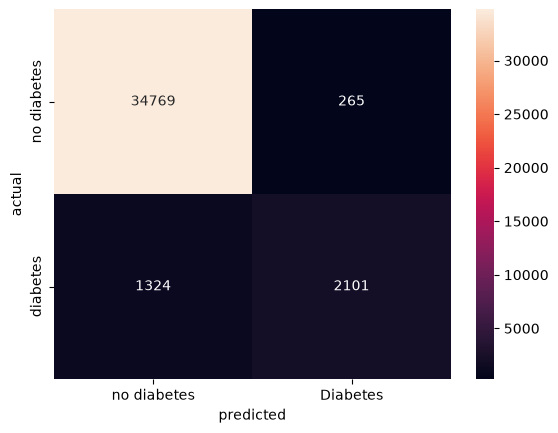

In [2347]:
sns.heatmap(data=cmknn,fmt='d',annot=True,xticklabels=['no diabetes','Diabetes'],yticklabels=['no diabetes','diabetes'])
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()

In [2348]:
from sklearn.metrics import precision_score,recall_score,roc_auc_score
precisionscrknn=precision_score(y_true=ytt,y_pred=pknn)
recall_scoreknn=recall_score(ytt,pknn)
predprob=knn.predict_proba(xtt_scaled)[:,1]
roc_auc_scoreknn=roc_auc_score(ytt,predprob)
print(f"prediction probablity : {predprob}\nprecision score : {precisionscrknn}\nrecall score : {recall_scoreknn}\nroc_auc score : {roc_auc_scoreknn}")

prediction probablity : [0.  0.  1.  ... 0.  0.2 0. ]
precision score : 0.8879966187658496
recall score : 0.6134306569343065
roc_auc score : 0.9047542554073644


In [2349]:
print(knn.classes_)

[0 1]


In [2350]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(xtr,ytr)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [2351]:
preddt=dt.predict(xtt)
preddt

array([0, 0, 1, ..., 0, 0, 0], shape=(38459,))

In [2352]:
ytt.shape

(38459,)

In [2353]:
print(sum(ytt<1))
sum(ytt>0)

35034


3425

In [2354]:
print(sum(ytt<1))
sum(preddt>0)

35034


np.int64(3617)

In [2355]:
preddtprob=dt.predict_proba(xtt)[:,1]
acscoredt=accuracy_score(ytt,preddt)
f1scrdt=f1_score(ytt,preddt)
roc_auc_scoredt=roc_auc_score(ytt,preddtprob)

print(f"predited probabilty of xtest data: {preddtprob}\naccuracy score : {acscoredt}\nF1 score : {f1scrdt}\nscore : {roc_auc_scoredt}")

predited probabilty of xtest data: [0. 0. 1. ... 0. 0. 0.]
accuracy score : 0.948776619256871
F1 score : 0.7202499289974439
score : 0.8548177515981348


In [2356]:
cmdt=confusion_matrix(ytt,preddt)
cmdt

array([[33953,  1081],
       [  889,  2536]])

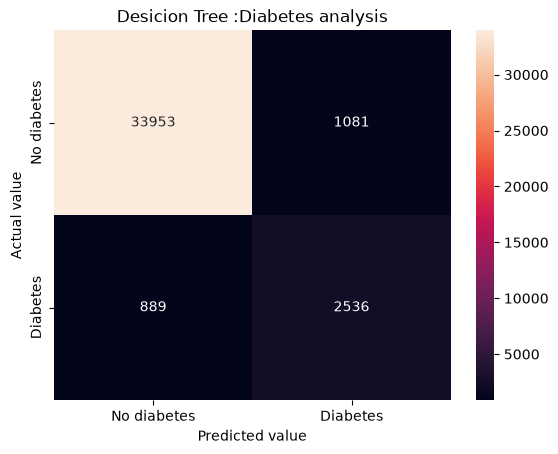

In [2357]:
sns.heatmap(data=cmdt,fmt='d',annot=True,xticklabels=['No diabetes','Diabetes'],yticklabels=['No diabetes','Diabetes'])
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Desicion Tree :Diabetes analysis")
plt.show()

In [2389]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(xtr,ytr)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [2390]:
predrf=rf.predict(xtt)
predrf

array([0, 0, 1, ..., 0, 0, 0], shape=(38459,))

In [2391]:
sum(predrf>0)

np.int64(2503)

In [2392]:
sum(ytt>0)

3425

In [2393]:
predrfprob=rf.predict_proba(xtt)[:,1];f1scrrf=f1_score(ytt,predrf);acscorerf=accuracy_score(ytt,predrf);roc_auc_scorerf=roc_auc_score(ytt,predrf)
print(f"predicted prob of y test: {predrfprob}\nF1 score : {f1scrrf}\naccuracy score : {acscorerf}\n roc_score : {roc_auc_scorerf}")
cmrf=confusion_matrix(ytt,predrf)
print("confusion matrix:\n",cmrf)
print('precision :')
precision_score(ytt,predrf)

predicted prob of y test: [0.   0.   1.   ... 0.   0.23 0.  ]
F1 score : 0.7958839406207827
accuracy score : 0.9685379235029512
 roc_score : 0.8423244156146125
confusion matrix:
 [[34890   144]
 [ 1066  2359]]
precision :


0.9424690371554135

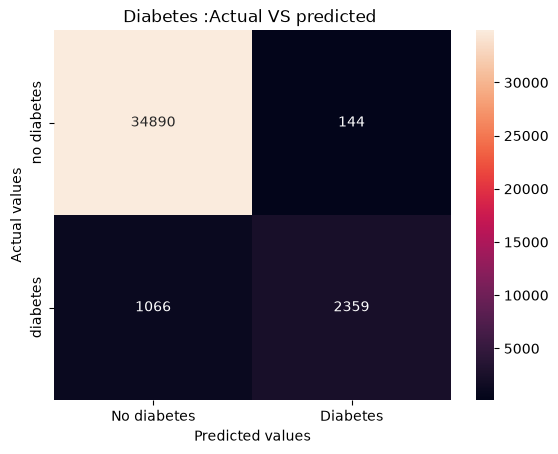

In [2394]:
sns.heatmap(data=cmrf,fmt='d',annot=True,xticklabels=['No diabetes','Diabetes'],yticklabels=['no diabetes','diabetes'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title("Diabetes :Actual VS predicted ")
plt.show()

In [2395]:
importance=pd.Series(
    rf.feature_importances_,
    index=xtr.columns
).sort_values(ascending=False)

In [2398]:
print("Based on Importance table :\n",importance)

Based on Importance table :
 HbA1c_level                    0.401491
blood_glucose_level            0.315527
bmi                            0.124416
age                            0.106775
hypertension                   0.016501
heart_disease                  0.011750
smoking_history_No Info        0.004172
smoking_history_former         0.003634
smoking_history_never          0.003595
gender_Male                    0.002582
gender_Female                  0.002494
smoking_history_current        0.002484
smoking_history_ever           0.002343
smoking_history_not current    0.002233
gender_Other                   0.000002
dtype: float64


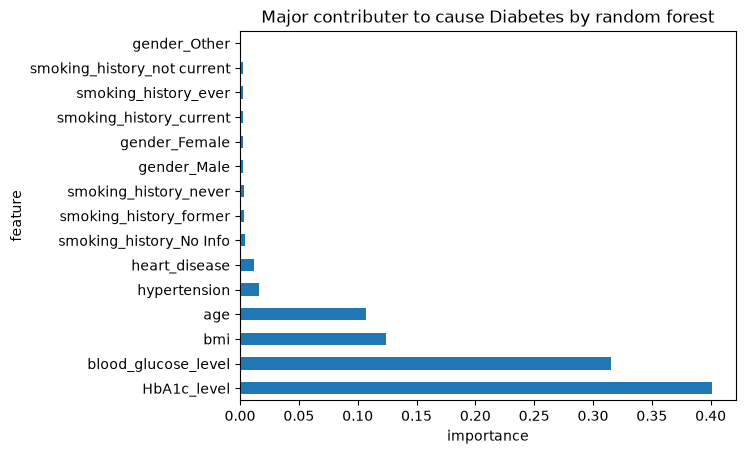

In [2402]:
plt.Figure(figsize=(10,7))
importance.plot(kind='barh')

plt.title("Major contributer to cause Diabetes by random forest")
plt.ylabel("feature")
plt.xlabel("importance")
plt.show()

In [ ]:
from  sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf= RandomForestClassifier(
    random_state=42
)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(xtr,ytr)
print("Best parameter :")
print(grid_search.best_params_)
print("Best CV f1 score: ")
print(grid_search.best_score_)
rftuned=grid_search.best_estimator_
print(rftuned)

{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
0.802116024827167
RandomForestClassifier(max_depth=30, min_samples_split=10, n_estimators=300,
                       random_state=42)


In [2406]:
rftuned_pred = rftuned.predict(xtt)
rftuned_prob= rftuned.predict_proba(xtt)[:,1]
print("tuned model score: ")
print("Accuracy :", accuracy_score(ytt, rftuned_pred))
print("Precision:", precision_score(ytt, rftuned_pred))
print("Recall   :", recall_score(ytt, rftuned_pred))
print("F1 Score :", f1_score(ytt, rftuned_pred))
print("ROC-AUC  :", roc_auc_score(ytt, rftuned_prob))

tuned model score: 
Accuracy : 0.9707740710886918
Precision: 0.9885350318471338
Recall   : 0.6797080291970803
F1 Score : 0.8055363321799308
ROC-AUC  : 0.9689851110224937


In [2408]:
print("Train shape:", xtr.shape)
print("Test shape :", xtt.shape)

print("Train index overlap:",
      len(set(xtr.index) & set(xtt.index)))

Train shape: (57687, 15)
Test shape : (38459, 15)
Train index overlap: 0


In [2409]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:

    pred = (rftuned_prob >= threshold).astype(int)

    print(
        "Threshold:", threshold,
        "| Accuracy:", round(accuracy_score(ytt, pred), 4),
        "| Precision:", round(precision_score(ytt, pred), 4),
        "| Recall:", round(recall_score(ytt, pred), 4),
        "| F1:", round(f1_score(ytt, pred), 4)
    )

Threshold: 0.2 | Accuracy: 0.9497 | Precision: 0.6873 | Recall: 0.7982 | F1: 0.7386
Threshold: 0.25 | Accuracy: 0.9606 | Precision: 0.7863 | Recall: 0.7658 | F1: 0.7759
Threshold: 0.3 | Accuracy: 0.9654 | Precision: 0.858 | Recall: 0.7323 | F1: 0.7902
Threshold: 0.35 | Accuracy: 0.969 | Precision: 0.9179 | Recall: 0.7153 | F1: 0.8041
Threshold: 0.4 | Accuracy: 0.9705 | Precision: 0.9584 | Recall: 0.6996 | F1: 0.8088
Threshold: 0.45 | Accuracy: 0.9708 | Precision: 0.9764 | Recall: 0.6888 | F1: 0.8077
Threshold: 0.5 | Accuracy: 0.9708 | Precision: 0.9885 | Recall: 0.6797 | F1: 0.8055


In [2410]:
final_pred = (rftuned_prob >= 0.40).astype(int)
final_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(38459,))

In [ ]:
plt.plot(pre)

In [2364]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
%matplotlib inline

In [2365]:
from sklearn.datasets import load_iris

In [2366]:
iris=load_iris()

In [2367]:
x=iris.data

In [2368]:
x.shape

(150, 4)

In [2369]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [2370]:
y=iris.target

In [2371]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [2372]:
df=pd.DataFrame(x,columns=iris.feature_names)

In [2373]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [2374]:
[iris.target_names[cls] for cls in y ]

[np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),


In [2375]:
df['species']=[iris.target_names[cls] for cls in y ]

In [2376]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [2377]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2378]:
df['species'].unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [2379]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [2380]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [2381]:
flowerclassifier=LogisticRegression()

In [2382]:
flowerclassifier.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [2383]:
predt_flower=flowerclassifier.predict(xtest)

In [2384]:
predt_flower

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [2385]:
ytest

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [2386]:
accuracy_score(ytest,predt_flower)

1.0

AttributeError: QuadMesh.set() got an unexpected keyword argument 'hue'

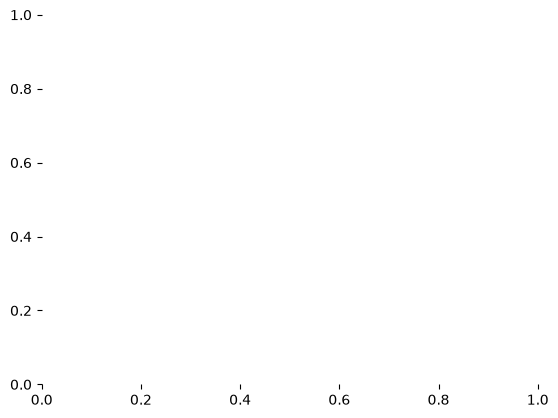

In [2387]:
sns.heatmap(data=confusion_matrix(ytest,predt_flower),annot=True,hue=" ")